# 1. Train Test Split

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split,KFold,StratifiedKFold,cross_val_score,StratifiedGroupKFold 
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

In [61]:
df = pd.read_csv("D:\INTERNSHIP PYTHON AI ML\Data Preprocessing\loan.csv")

<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\SAMBIT\AppData\Local\Temp\ipykernel_17836\3846328725.py:1: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  df = pd.read_csv("D:\INTERNSHIP PYTHON AI ML\Data Preprocessing\loan.csv")


In [62]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [63]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [64]:
X = df.drop(columns="Loan_Status")
X

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban


In [65]:
y = df.Loan_Status
y

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: str

In [66]:
y.value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

In [67]:
y.value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [68]:
def check_ratio(y):
  d = {
        "Count":y.value_counts(),
        "Percentage":round(y.value_counts(normalize=True),3)
  }
  y_ratio = pd.DataFrame(d)
  return y_ratio

In [69]:
check_ratio(y)

,Count,Percentage
Loan_Status,,
Y,422,0.687
N,192,0.313


# 2. Handling Missing Values

In [70]:
def missing_report(df):
    missing_summary = pd.DataFrame(
        {
            "missing_count": df.isna().sum().sort_values(ascending=False),
            "missing_percent": (df.isna().mean() * 100).sort_values(ascending=False)
        }
    )
    return missing_summary
missing_report(df)

,missing_count,missing_percent
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Education,0,0.000000
Loan_ID,0,0.000000
CoapplicantIncome,0,0.000000


In [71]:
print("Shape Dataset -> ", df.shape)
print("Shape X -> ", X.shape)
print("Shape y -> ", y.shape)

Shape Dataset ->  (614, 13)
Shape X ->  (614, 12)
Shape y ->  (614,)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [73]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [74]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [75]:
numerical = ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term"]
categorical = ["Loan_ID","Gender","Married","Dependents","Education","Self_Employed","Credit_History","Property_Area"] 

In [76]:
for i in numerical:
    X_train_avg = X_train[i].mean()
    X_train[i] = X_train[i].fillna(X_train_avg)
    X_test[i] = X_test[i].fillna(X_train_avg)

missing_report(X_train)

,missing_count,missing_percent
Credit_History,43,8.757637
Self_Employed,27,5.498982
Gender,11,2.240326
Dependents,8,1.629328
Married,3,0.610998
Loan_ID,0,0.000000
ApplicantIncome,0,0.000000
Education,0,0.000000
CoapplicantIncome,0,0.000000
LoanAmount,0,0.000000


In [77]:
for i in categorical:
    X_train_mode = X_train[i].mode()[0]
    X_train[i] = X_train[i].fillna(X_train_mode)
    X_test[i] = X_test[i].fillna(X_train_mode)

missing_report(X_train)

,missing_count,missing_percent
Loan_ID,0,0.0
Gender,0,0.0
Married,0,0.0
Dependents,0,0.0
Education,0,0.0
Self_Employed,0,0.0
ApplicantIncome,0,0.0
CoapplicantIncome,0,0.0
LoanAmount,0,0.0
Loan_Amount_Term,0,0.0


In [78]:
missing_report(X_test)

,missing_count,missing_percent
Loan_ID,0,0.0
Gender,0,0.0
Married,0,0.0
Dependents,0,0.0
Education,0,0.0
Self_Employed,0,0.0
ApplicantIncome,0,0.0
CoapplicantIncome,0,0.0
LoanAmount,0,0.0
Loan_Amount_Term,0,0.0


In [79]:
y.isna().sum()

np.int64(0)

In [80]:
train_loan = pd.concat([X_train, y_train], axis=1)
test_loan = pd.concat([X_test, y_test], axis=1)

train_loan.to_csv("train_loan.csv", index=False)
test_loan.to_csv("test_loan.csv", index=False)

# 3. Encoding

In [81]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
train = pd.read_csv("train_loan.csv")
test = pd.read_csv("test_loan.csv")

X_train = train.drop(columns='Loan_Status') 
y_train = train["Loan_Status"]
X_test = test.drop(columns='Loan_Status') 
y_test = test["Loan_Status"]

In [83]:
print("Shape Dataset -> ", X_train.shape)
print("Shape X -> ", X_test.shape)
print("Shape y -> ", y_train.shape)

Shape Dataset ->  (491, 12)
Shape X ->  (123, 12)
Shape y ->  (491,)


In [84]:
X_train.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001535,Male,No,0,Graduate,No,3254,0.0,50.0,360.0,1.0,Urban
1,LP001792,Male,Yes,1,Graduate,No,3315,0.0,96.0,360.0,1.0,Semiurban
2,LP002443,Male,Yes,2,Graduate,No,3340,1710.0,150.0,360.0,0.0,Rural


In [85]:
ord_bin_cat = ["Education", "Dependents"]
nominal_cat = ["Gender", "Married","Self_Employed","Credit_History","Property_Area"]
to_remove = ["Loan_ID"]

In [86]:
X_train = X_train.drop(columns=to_remove)
X_test = X_test.drop(columns=to_remove)

# Label Encoding

In [87]:
ord_bin_cat = ["Education", "Dependents"]

label_enc_classes = {}

for i in ord_bin_cat:
    le = LabelEncoder()
    le.fit(X_train[i])
    X_train[i] = le.transform(X_train[i])
    X_test[i] = le.transform(X_test[i])
    
    label_enc_classes[i] = le
    
label_enc_classes

{'Education': LabelEncoder(), 'Dependents': LabelEncoder()}

In [88]:
label_enc_classes = {}
le = LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)
label_enc_classes = le

label_enc_classes

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](2,)","['N','Y']"


In [89]:
y_train = pd.Series(y_train)

In [90]:
X_train.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,0,No,3254,0.0,50.0,360.0,1.0,Urban
1,Male,Yes,1,0,No,3315,0.0,96.0,360.0,1.0,Semiurban
2,Male,Yes,2,0,No,3340,1710.0,150.0,360.0,0.0,Rural


In [91]:
X_test.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,0,No,6277,0.0,118.0,360.0,0.0,Rural
1,Female,Yes,0,0,No,4180,2306.0,182.0,360.0,1.0,Semiurban
2,Male,Yes,0,0,Yes,9963,0.0,180.0,360.0,1.0,Rural


# One Hot Encoding

In [92]:
nominal_cat = ["Gender", "Married","Self_Employed","Credit_History","Property_Area"]
print("Nominal categorical features are : ", nominal_cat)

Nominal categorical features are :  ['Gender', 'Married', 'Self_Employed', 'Credit_History', 'Property_Area']


In [93]:
# Step 2: Create class instance 
ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

# Step 3 : Fit train data
ohe.fit(X_train[nominal_cat])

,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",'first'
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infre

In [94]:
# Extracting encoded columns to use as column heading in dataframe
ohe_encoded_cols = ohe.get_feature_names_out()
print(ohe_encoded_cols)

['Gender_Male' 'Married_Yes' 'Self_Employed_Yes' 'Credit_History_1.0'
 'Property_Area_Semiurban' 'Property_Area_Urban']


In [95]:
#Step 4: transform train and test data and store the result in variable
train_encoded = ohe.transform(X_train[nominal_cat])
test_encoded = ohe.transform(X_test[nominal_cat])

In [96]:
#Step 5: Convert the step 4 result to dataframe and use columns extracted above
train_df = pd.DataFrame(train_encoded, columns=ohe_encoded_cols, index=X_train.index)
test_df = pd.DataFrame(test_encoded, columns=ohe_encoded_cols, index=X_test.index)
#train_df.head()

In [97]:
#Step 6: Drop nominal_categories created in step 1 from X_train and X_test
X_train = X_train.drop(columns=nominal_cat)
X_test = X_test.drop(columns=nominal_cat)

In [98]:
#Step 7: Concatenate the encoded df and original df - both train and test
X_train = pd.concat([X_train, train_df], axis=1)
X_test = pd.concat([X_test, test_df], axis=1)

X_train.head()

,Dependents,Education,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Gender_Male,Married_Yes,Self_Employed_Yes,Credit_History_1.0,Property_Area_Semiurban,Property_Area_Urban
0,0,0,3254,0.0,50.0,360.0,1.0,0.0,0.0,1.0,0.0,1.0
1,1,0,3315,0.0,96.0,360.0,1.0,1.0,0.0,1.0,1.0,0.0
2,2,0,3340,1710.0,150.0,360.0,1.0,1.0,0.0,0.0,0.0,0.0
3,1,1,2653,1500.0,113.0,180.0,1.0,1.0,0.0,0.0,0.0,0.0
4,0,0,2620,2223.0,150.0,360.0,1.0,1.0,0.0,1.0,1.0,0.0


# 4. Outliers

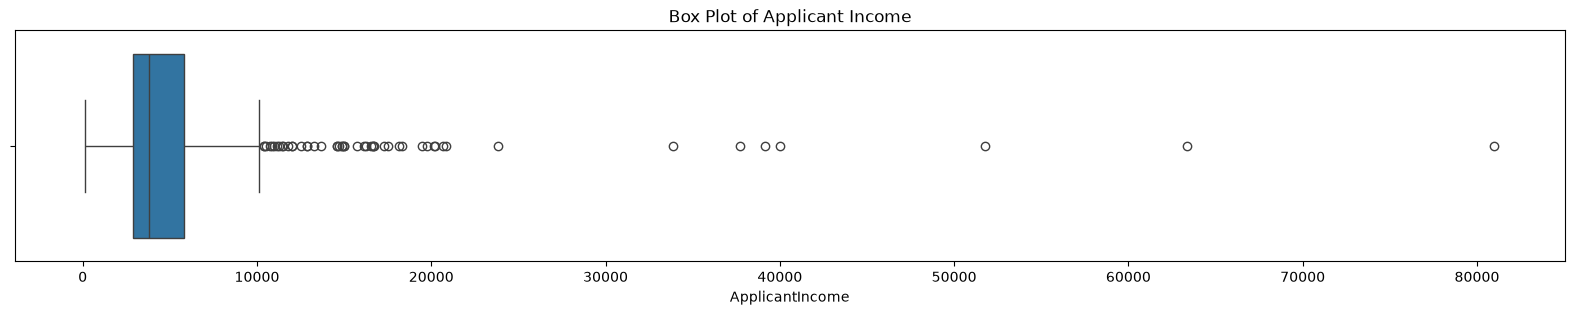

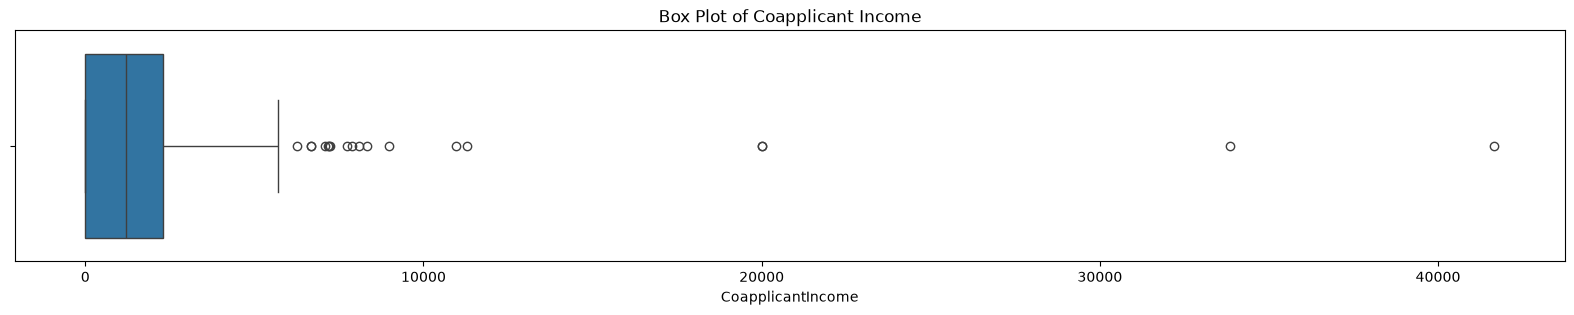

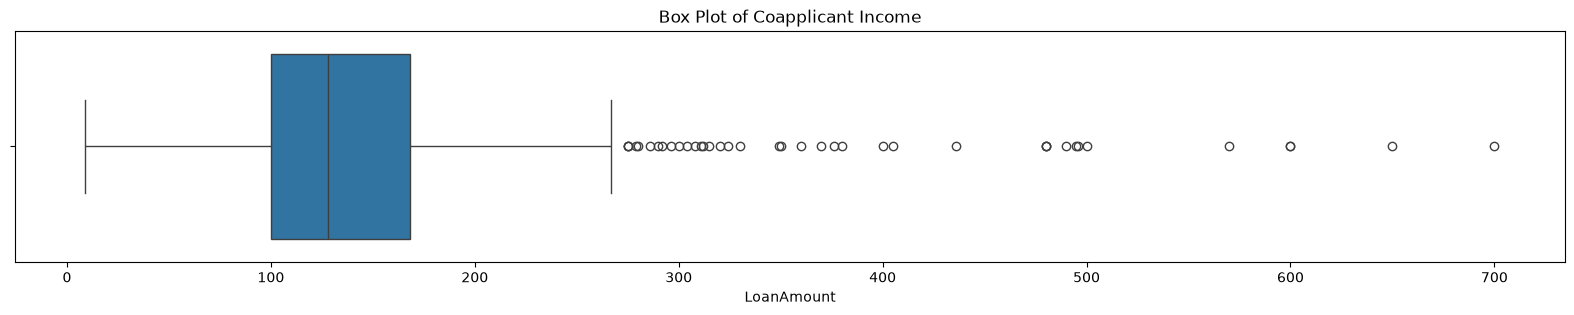

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure (figsize= (20, 3))

# Plot boxplot for ApplicantIncome
sns.boxplot(x=df['ApplicantIncome'])
plt.title('Box Plot of Applicant Income')
plt.show()

plt.figure (figsize= (20, 3))
sns.boxplot(x=df['CoapplicantIncome'])
plt.title('Box Plot of Coapplicant Income')
plt.show()

plt.figure (figsize= (20, 3))
sns.boxplot(x=df['LoanAmount'])
plt.title('Box Plot of Coapplicant Income')
plt.show()

# 5. Handling Imbalanced Data

In [100]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, RandomOverSampler

In [101]:
check_ratio(y)

,Count,Percentage
Loan_Status,,
Y,422,0.687
N,192,0.313


In [102]:
smote = SMOTE(random_state=42)
X_train_so, y_train_so = smote.fit_resample(X_train, y_train)

In [103]:
check_ratio(y_train_so)

,Count,Percentage
1,337,0.5
0,337,0.5


# 6. Pipeline

In [104]:
pipeline = Pipeline([
  ("scaler",StandardScaler()),
  ("model",LogisticRegression())
])
pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Dependents','Education','ApplicantIncome',...,'Credit_History_1.0', 'Property_Area_Semiurban','Property_Area_Urban']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [105]:
train_pred = pipeline.predict(X_train)
test_pred = pipeline.predict(X_test)

prob_train = pipeline.predict_proba(X_train)
prob_test = pipeline.predict_proba(X_test)

# 8. Predictions

In [106]:
skf = StratifiedKFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

In [107]:
score = cross_val_score(
  pipeline,
  X_train,
  y_train,
  scoring="accuracy",
  cv=skf
)

score.mean()

np.float64(0.7982683982683982)

In [108]:
G = df["Loan_ID"]

In [109]:
sgf = StratifiedGroupKFold(
  n_splits=5,
  shuffle=True,
  random_state=42
)

# 9. Evaluation Metric (Train & Test)

In [110]:
def print_metrics(title, y_true, y_pred):
    acc = accuracy_score(y_true,y_pred )   # (test_labels, prediction_labels)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(title)
    print(f"  Accuracy: {acc:.2%}")
    print(f"  Precision: {prec:.2%}")
    print(f"  Recall: {rec:.2%}")
    print(f"  F1-score: {f1:.2%}")

In [111]:
print_metrics("TRAIN METRICS", y_train, train_pred)
print_metrics("TEST METRICS", y_test, test_pred)

TRAIN METRICS
  Accuracy: 80.04%
  Precision: 78.25%
  Recall: 98.22%
  F1-score: 87.11%
TEST METRICS
  Accuracy: 86.18%
  Precision: 84.00%
  Recall: 98.82%
  F1-score: 90.81%


Confusion Matrix
[[ 62  92]
 [  6 331]]


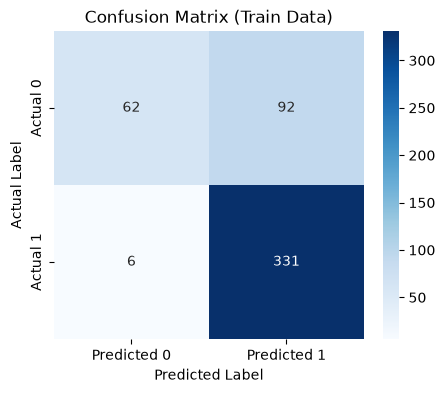

In [112]:
cm = confusion_matrix(y_train, train_pred)

print("Confusion Matrix")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"],fmt=".0f")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Train Data)")
plt.show()

Confusion Matrix
[[22 16]
 [ 1 84]]


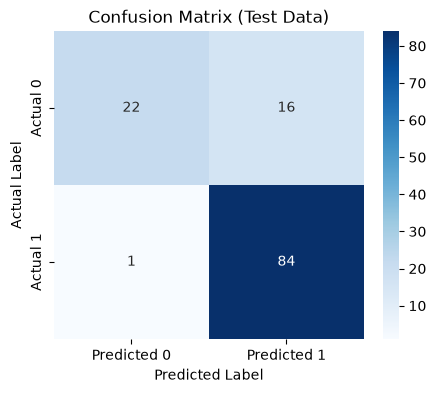

In [113]:
cm = confusion_matrix(y_test, test_pred)

print("Confusion Matrix")
print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix (Test Data)")
plt.show()

# 10. ROC Curve + AUC

In [114]:
fpr, tpr, thresholds = roc_curve(y_test, prob_test)
auc_score = roc_auc_score(y_test, prob_test)

print(f"ROC AUC Score: {auc_score:.3f}")

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0, 1], linestyle="--")
plt.xlabel("False Positve Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

ValueError: y should be a 1d array, got an array of shape (123, 2) instead.